In [4]:
pip install mysql-connector-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import mysql.connector

In [28]:
conn = mysql.connector.connect(
host="localhost",
user="root",
password="Ichwill1hund.",
database="db_companies"
)

In [31]:
cursor=conn.cursor()

In [43]:
cursor.execute("SHOW TABLES")
print("Tablas en la base de datos:")
for tabla in cursor.fetchall():
    print(tabla[0])

Tablas en la base de datos:
companies
credit_cards
estado_tarjetas
productos
transactions
transactions_products
user


In [19]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
companies_df = pd.read_sql("SELECT * FROM companies", conn)
credit_cards_df = pd.read_sql("SELECT * FROM credit_cards", conn)
estado_tarjetas_df = pd.read_sql("SELECT * FROM estado_tarjetas", conn)
productos_df = pd.read_sql("SELECT * FROM productos", conn)
transactions_df = pd.read_sql("SELECT * FROM transactions", conn)
transactions_products_df = pd.read_sql("SELECT * FROM transactions_products", conn)
user_df = pd.read_sql("SELECT * FROM user", conn)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22128\8480795.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  companies_df = pd.read_sql("SELECT * FROM companies", conn)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_22128\8480795.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  credit_cards_df = pd.read_sql("SELECT * FROM credit_cards", conn)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_22128\8480795.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  estado_tarjetas_df = pd.read_sql("SELECT * FROM estado_tarjetas", c

In [46]:
conn.close()

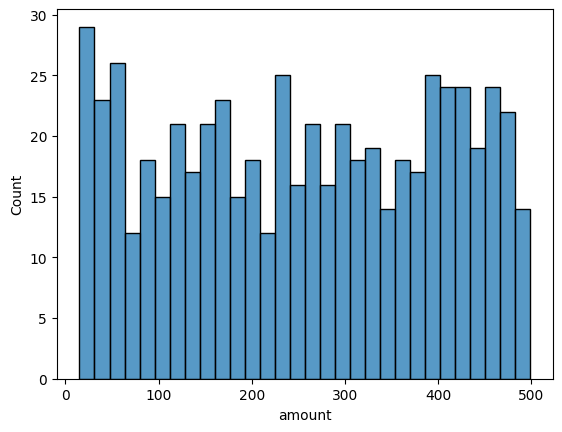

In [ ]:
sns.histplot(transactions_df["amount"], bins=30)
plt.show()

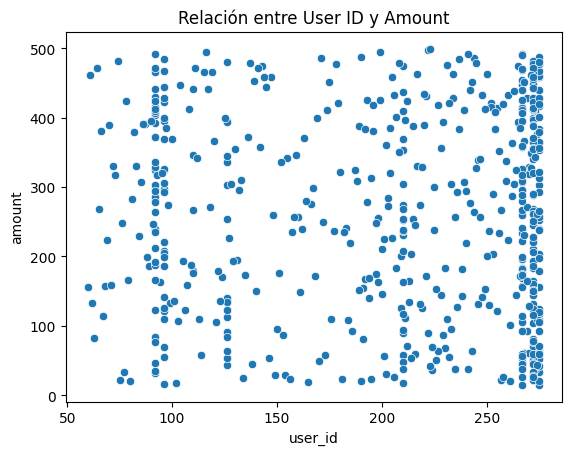

In [89]:
sns.scatterplot(data=transactions_df, x="user_id", y="amount")
plt.title("Relación entre User ID y Amount")
plt.show()

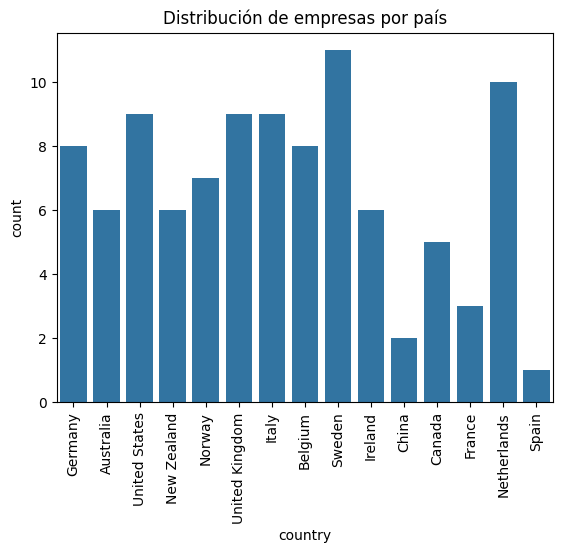

In [90]:
sns.countplot(x="country", data=companies_df)
plt.xticks(rotation=90)
plt.title("Distribución de empresas por país")
plt.show()

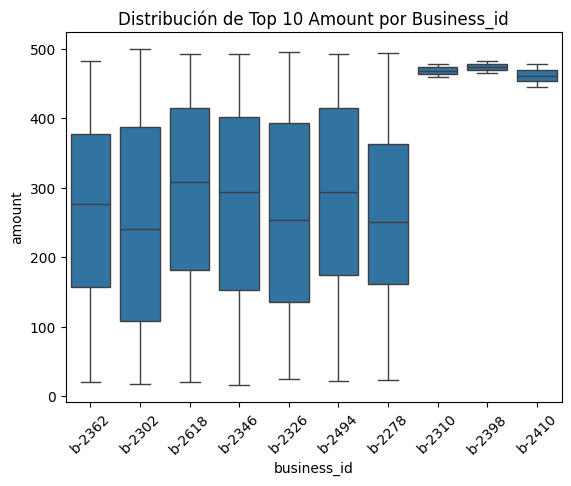

In [103]:
top10 = transactions_df.groupby("business_id")["amount"].sum().sort_values(ascending=False).head(10).index
top10_df = transactions_df[transactions_df["business_id"].isin(top10)]
sns.boxplot(x="business_id", y="amount", data=top10_df)
plt.xticks(rotation=45)
plt.title("Distribución de Top 10 Amount por Business_id")
plt.show()

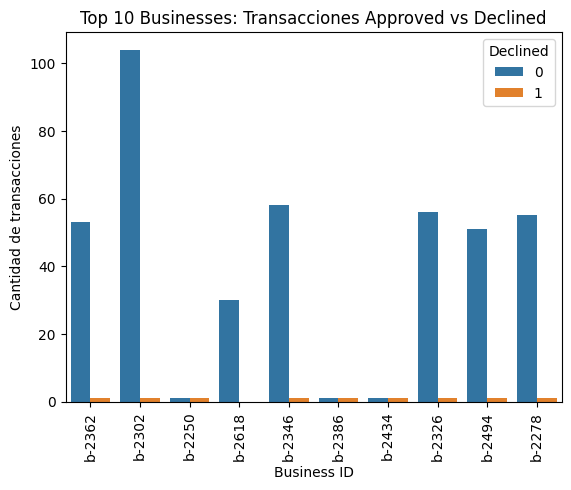

In [138]:
top10_businesses = transactions_df['business_id'].value_counts().head(10).index
top10_df = transactions_df[transactions_df['business_id'].isin(top10_businesses)]

sns.countplot(x='business_id', hue='declined', data=top10_df)
plt.xticks(rotation=90)
plt.title("Top 10 Businesses: Transacciones Approved vs Declined")
plt.xlabel("Business ID")
plt.ylabel("Cantidad de transacciones")
plt.legend(title="Declined")
plt.show()

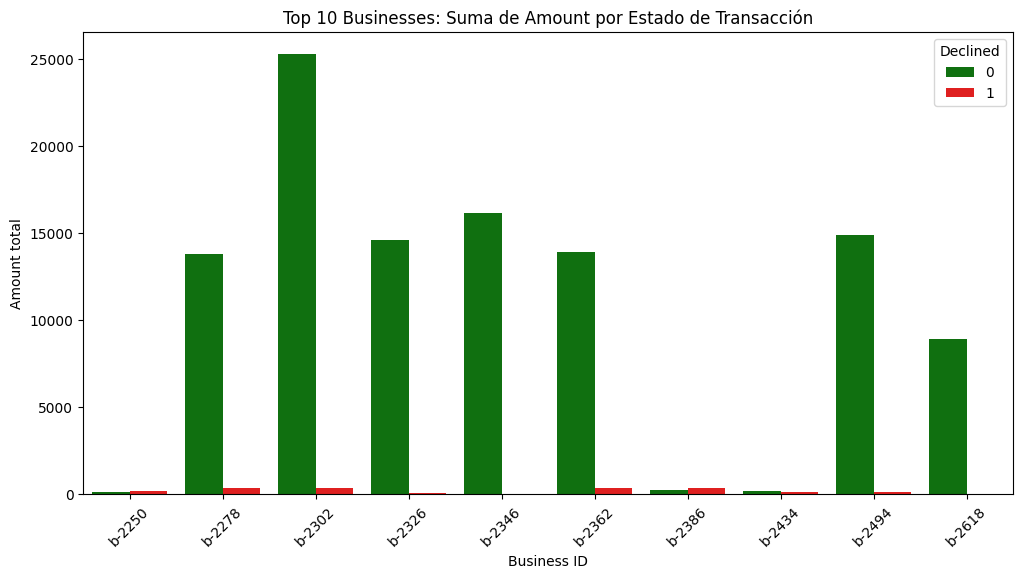

In [ ]:
top10_businesses = transactions_df['business_id'].value_counts().head(10).index
top10_df = transactions_df[transactions_df['business_id'].isin(top10_businesses)]

summary = top10_df.groupby(['business_id', 'declined'])['amount'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.barplot(x='business_id', y='amount', hue='declined', data=summary, palette=['green','red'])
plt.xticks(rotation=45)
plt.title("Top 10 Businesses: Suma de Amount por Estado de Transacción")
plt.xlabel("Business ID")
plt.ylabel("Amount total")
plt.legend(title="Declined")
plt.show()




In [ ]:
merged_df = transactions_df.merge(user_df[['id','country']], left_on='user_id', right_on='id')

user_summary = merged_df.groupby(['user_id','country']).size().reset_index(name='num_transactions')

print(user_summary)


     user_id        country  num_transactions
0         60  United States                 1
1         61  United States                 1
2         62  United States                 1
3         63  United States                 1
4         64  United States                 1
..       ...            ...               ...
211      271         Canada                 4
212      272         Canada                76
213      273         Canada                 4
214      274         Canada                 4
215      275         Canada                48

[216 rows x 3 columns]


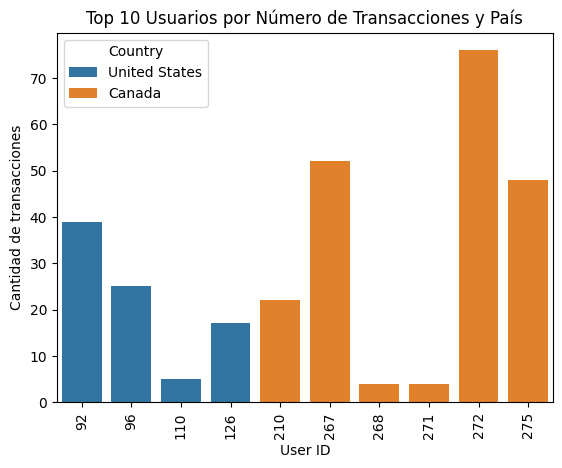

In [ ]:

top_users = user_summary.sort_values('num_transactions', ascending=False).head(10)


sns.barplot(x='user_id', y='num_transactions', hue='country', data=top_users)
plt.xticks(rotation=90)
plt.title("Top 10 Usuarios por Número de Transacciones y País")
plt.xlabel("User ID")
plt.ylabel("Cantidad de transacciones")
plt.legend(title="Country")
plt.show()


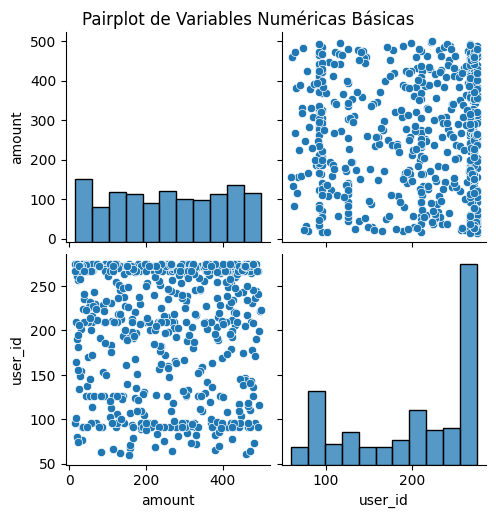

In [ ]:
pairplot_df = transactions_df[['amount','user_id','business_id']]

sns.pairplot(pairplot_df)
plt.suptitle("Pairplot de Variables Numéricas Básicas", y=1.02)
plt.show()

